In [10]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import *
from mis_dro.experiments import ExperimentName
from mis_dro.results import preprocess_results_df, is_minimise_pareto_front, get_agg_df, get_result_df_list, convert_str_to_float_list


from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":14})
rc('text', usetex=True)

In [11]:
# cv_kl_newsvendor_dir = Path("/dcs/large/u1508153/misdro/cv_newsvendor_different_replications")
# cv_kl_newsvendor_dir = Path("/Users/patrick/Experiments/misdro/2025_03_28_cross_validation/cv_newsvendor_different_replications")
cv_kl_newsvendor_dir = Path("/Users/patrick/Experiments/misdro/2025_03_28_cross_validation/cv_kl_newsvendor_1d")

cv_kl_newsvendor_df = pd.read_csv(cv_kl_newsvendor_dir / "results.csv", index_col=["uuid", "replication"])

cv_kl_newsvendor_df = cv_kl_newsvendor_df.loc[cv_kl_newsvendor_df["algorithm"].isin(['kl_pp', 'kl_dro_bas'])]

splits_df = cv_kl_newsvendor_df.loc[~cv_kl_newsvendor_df["use_cv_epsilon"]]
cv_df = cv_kl_newsvendor_df.loc[cv_kl_newsvendor_df["use_cv_epsilon"]]

In [12]:
filter_dgp = "normal"  # filter by DGP
results_df = preprocess_results_df(splits_df, filter_dgp)
results_df.head(3)

solution  \
uuid                                 replication                         
ff656d45-d92f-4977-8077-7bcff1c29679 0            [31.452356647780974]   
                                     1             [26.45344288553397]   
                                     2             [30.25922983644443]   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
ff656d45-d92f-4977-8077-7bcff1c29679 0            0.003274         0.000137   
                                     1            0.000702         0.000105   
                                     2            0.000679         0.000107   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
ff656d45-d92f-4977-8077-7bcff1c29679 0                  0.000107    0.140313   
                                     1                  0.000067    0.030750   
                                     2                  0.000065    0.030499   

                                                  setup_time  \
uuid                                 replication               
ff656d45-d92f-4977-8077-7bcff1c29679 0                   NaN   
                                     1                   NaN   
                                     2                   NaN   

                                                  log_partition_constant  \
uuid                                 replication                           
ff656d45-d92f-4977-8077-7bcff1c29679 0                               0.0   
                                     1                               0.0   
                                     2                               0.0   

                                                                                 out_of_sample_cost  \
uuid                                 replication                                                      
ff656d45-d92f-4977-8077-7bcff1c29679 0            [35.42715113817625, 67.85563843541308, 105.201...   
                                     1            [43.45504560473274, 34.86190525143647, 4.11606...   
                                     2            [5.860559265273505, 25.242872784764558, 63.873...   

                                                 algorithm  contamination  \
uuid                                 replication                            
ff656d45-d92f-4977-8077-7bcff1c29679 0               kl_pp            0.0   
                                     1               kl_pp            0.0   
                                     2               kl_pp            0.0   

                                                  ... do_cross_validation  \
uuid                                 replication  ...                       
ff656d45-d92f-4977-8077-7bcff1c29679 0            ...                True   
                                     1            ...                True   
                                     2            ...                True   

                                                 n_splits  epsilon  split_idx  \
uuid                                 replication                                
ff656d45-d92f-4977-8077-7bcff1c29679 0                 10    0.001        0.0   
                                     1                 10    0.001        0.0   
                                     2                 10    0.001        0.0   

                                                 use_cv_epsilon  cv_uuid_list  \
uuid                                 replication                                
ff656d45-d92f-4977-8077-7bcff1c29679 0                    False            []   
                                     1                    False            []   
                                     2                    False            []   

                                                 num_total_samples  \
uuid                  

In [13]:
cv_df = preprocess_results_df(cv_df, filter_dgp, dataset="newsvendor")
cv_agg_df = get_agg_df(cv_df, ["algorithm", "num_total_samples"])
cv_agg_df

/Users/patrick/Projects/mis-dro-code/mis_dro/results.py:66: FutureWarning: The provided callable <function mean at 0x10ce998a0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/Users/patrick/Projects/mis-dro-code/mis_dro/results.py:66: FutureWarning: The provided callable <function std at 0x10ce999e0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  out_of_sample_var  \
algorithm  num_total_samples                                          
kl_dro_bas 25                          38.037242         851.679843   
           100                         37.156579         788.432946   
           900                         36.769357         773.157071   
kl_pp      25                          37.787318         850.783530   
           100                         37.007467         796.465846   
           900                         36.686048         800.699330   

                              out_of_sample_std  sum_of_in_group_var  \
algorithm  num_total_samples                                           
kl_dro_bas 25                         29.183554           833.333149   
           100                        28.079048           773.229178   
           900                        27.805702           758.667454   
kl_pp      25                         29.168194           828.923862   
           100                        28.221726           780.549798   
           900                        28.296631           785.510926   

                              var_of_in_group_mean  mean_solve_time  \
algorithm  num_total_samples                                          
kl_dro_bas 25                            18.346693         0.023592   
           100                           15.203768         0.034924   
           900                           14.489616         0.410834   
kl_pp      25                            21.859668         0.024355   
           100                           15.916047         0.036235   
           900                           15.188403         0.432729   

                              std_solve_time  mean_sample_time  \
algorithm  num_total_samples                                     
kl_dro_bas 25                       0.000638          0.000063   
           100                      0.006291          0.000069   
           900                      0.014059          0.000092   
kl_pp      25                       0.006270          0.000127   
           100                      0.001050          0.000135   
           900                      0.017043          0.000184   

                              std_sample_time  
algorithm  num_total_samples                   
kl_dro_bas 25                        0.000005  
           100                       0.000009  
           900                       0.000008  
kl_pp      25                        0.000010  
           100                       0.000009  
           900                       0.000009

In [14]:
agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "inference", "num_total_samples", "num_observations"])
agg_df

/Users/patrick/Projects/mis-dro-code/mis_dro/results.py:66: FutureWarning: The provided callable <function mean at 0x10ce998a0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/Users/patrick/Projects/mis-dro-code/mis_dro/results.py:66: FutureWarning: The provided callable <function std at 0x10ce999e0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  \
algorithm  dgp    epsilon inference num_total_samples num_observations                       
kl_dro_bas normal 0.02    bayes     25                100                        37.609382   
                                    100               100                        36.930514   
                                    900               100                        36.609835   
                  0.03    bayes     25                100                        37.622189   
                                    100               100                        36.984554   
...                                                                                    ...   
kl_pp      normal 2.50    bayes     100               100                        43.901629   
                                    900               100                        47.529628   
                  3.00    bayes     25                100                        40.319151   
                                    100               100                        44.045588   
                                    900               100                        48.592314   

                                                                        out_of_sample_var  \
algorithm  dgp    epsilon inference num_total_samples num_observations                      
kl_dro_bas normal 0.02    bayes     25                100                      835.519333   
                                    100               100                      782.775822   
                                    900               100                      775.183557   
                  0.03    bayes     25                100                      825.113941   
                                    100               100                      773.600726   
...                                                                                   ...   
kl_pp      normal 2.50    bayes     100               100                      763.694874   
                                    900               100                      757.970067   
                  3.00    bayes     25                100                      807.707431   
                                    100               100                      768.048166   
                                    900               100                      775.159260   

                                                                        out_of_sample_std  \
algorithm  dgp    epsilon inference num_total_samples num_observations                      
kl_dro_bas normal 0.02    bayes     25                100                       28.905351   
                                    100               100                       27.978131   
                                    900               100                       27.842118   
                  0.03    bayes     25                100                       28.724797   
                                    100               100                       27.813679   
...                                                                                   ...   
kl_pp      normal 2.50    bayes     100               100                       27.635030   
                                    900               100                       27.531256   
                  3.00    bayes     25                100                       28.420194   
                                    100               100                       27.713682   
                                    900               100                       27.841682   

                                                                        sum_of_in_group_var  \
algorithm  dgp    epsilon inference num_total_samples num_observations                        
kl_dro_bas normal 0.02    bayes     25                100                       8082.018289   
                                    100               100                       7607.493294   
                                    900          

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

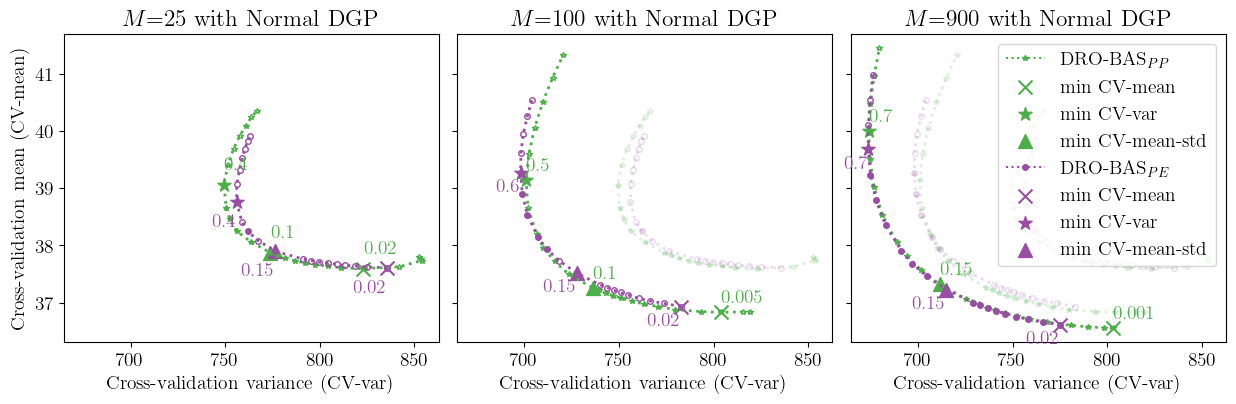

In [26]:
total_samples_list = agg_df.loc[~(agg_df.index.get_level_values("algorithm").isin(("kl_empirical", "wasserstein_empirical")))].index.get_level_values("num_total_samples").unique().tolist()
# num_observations_list = agg_df.index.get_level_values("num_observations").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = len(dgp_list)
ncols = len(total_samples_list)
# ncols = len(num_observations_list)
trim_epsilon = 1.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*4))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
for i, dgp in enumerate(dgp_list):
    for j, total_samples in enumerate(total_samples_list):
    # for j, num_observations in enumerate(num_observations_list):

        # NOTE empirical KL doesn't sample, so we plot it before filtering by total_samples
        # mean_variance_plot(axes[j], agg_df.loc["kl_empirical", dgp, :trim_epsilon, "empirical", :, :], **algorithm_inference_style("kl_empirical", "empirical", label_inference=False), special_epsilons=[0.3], offset=0.1)
        # mean_variance_plot(axes[j], agg_df.loc["kl_empirical", dgp, :trim_epsilon, "empirical", num_observations, :], **algorithm_inference_style("kl_empirical", "empirical", label_inference=False), special_epsilons=[0.3], offset=0.1)
        # mean_variance_plot(axes[j], agg_df.loc["wasserstein_empirical", dgp, :, "empirical", :, :], **algorithm_inference_style("wasserstein_empirical", "empirical", label_inference=False), special_epsilons=[0.3], offset=0.1)


        # filter by the total samples and DGP
        axis_df = agg_df.loc[:, dgp, :, :, total_samples, :]
        # axis_df = agg_df.loc[:, dgp, :, :, :, num_observations]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm, inference in set(zip(axis_df.index.get_level_values("algorithm"), axis_df.index.get_level_values("inference"))):
            df = axis_df.loc[algorithm, :trim_epsilon, :, :]

            if algorithm == "kl_bdro":
                print("All BDRO points are Pareto dominated for M =", total_samples, "?", not df["is_pareto_front"].any())

            min_vf_mean_row = df.loc[df["out_of_sample_mean"] == df["out_of_sample_mean"].min()].iloc[0]
            min_vf_var_row = df.loc[df["out_of_sample_var"] == df["out_of_sample_var"].min()].iloc[0]


            weighted_VF = 0.5 * (df["out_of_sample_mean"] + df["out_of_sample_std"])
            vf_comprimise_row = df.loc[weighted_VF == weighted_VF.min()].iloc[0]

            special_epsilons = [min_vf_mean_row.name[1], vf_comprimise_row.name[1], min_vf_var_row.name[1]]

            for k in range(j, len(total_samples_list)):
            # for k in range(j, len(num_observations_list)):
                alpha = 1.0
                is_labelled=True
                if j != k:
                    alpha = 0.2
                    is_labelled = False
                if j == 0:
                    offset = 0.2
                else:
                    offset = 0.1
                mean_variance_plot(axes[k], df, **algorithm_inference_style(algorithm, inference, label_inference=False), offset=offset, is_labelled=is_labelled, alpha=alpha, special_epsilons=special_epsilons, add_end_epsilons=False)
            
            axes[j].scatter(min_vf_mean_row["out_of_sample_var"], min_vf_mean_row["out_of_sample_mean"], marker="x", color=AlgorithmColor[algorithm].value, label="$\min$ CV-mean", s=100)
            axes[j].scatter(min_vf_var_row["out_of_sample_var"], min_vf_var_row["out_of_sample_mean"], marker="*", color=AlgorithmColor[algorithm].value, label="$\min$ CV-var", s=100)
            axes[j].scatter(vf_comprimise_row["out_of_sample_var"], vf_comprimise_row["out_of_sample_mean"], marker="^", color=AlgorithmColor[algorithm].value, label="$\min$ CV-mean-std", s=100)

        if j == 0:
            axes[j].set_ylabel("Cross-validation mean (CV-mean)")
        if j==2:
            handles, labels = axes[j].get_legend_handles_labels()
            algorithm_order = [AlgorithmName.kl_dro_bas.value, AlgorithmName.kl_pp.value]
            # algorithm_order = [AlgorithmName.kl_dro_bas.value, AlgorithmName.kl_pp.value, AlgorithmName.kl_bdro.value, AlgorithmName.wasserstein_empirical.value]
            # order = [list(labels).index(a) for a in algorithm_order]
            # axes[j].legend([handles[idx] for idx in order],[labels[idx] for idx in order])
            axes[j].legend()
        axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        # axes[j].set_title("$n$" + f"={num_observations} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Cross-validation variance (CV-var)")        


fig.savefig(f"/Users/patrick/Experiments/misdro/2025_03_28_cross_validation/splits_newsvendor_{filter_dgp}_100_observations.pdf", bbox_inches="tight")

**Plot the OOS mean and variance when we solve with $\epsilon_\text{CV}^j$ for each iteration $j$**

In [16]:
# get the experiment that contains Newsvendor results for Normal DGP with 100 observations (instead of the usual 20)
experiment_100_dir = Path(f"/Users/patrick/experiments/misdro/2025_03_28_cross_validation/newsvendor_100")
all_results_100_df = pd.read_csv(experiment_100_dir / "results.csv", index_col=["uuid", "replication"])
results_100_df = preprocess_results_df(all_results_100_df, filter_dgp)
agg_100_df = get_agg_df(results_100_df, ["algorithm", "dgp", "epsilon", "inference", "num_total_samples", "num_observations"])


/Users/patrick/Projects/mis-dro-code/mis_dro/results.py:66: FutureWarning: The provided callable <function mean at 0x10ce998a0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/Users/patrick/Projects/mis-dro-code/mis_dro/results.py:66: FutureWarning: The provided callable <function std at 0x10ce999e0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


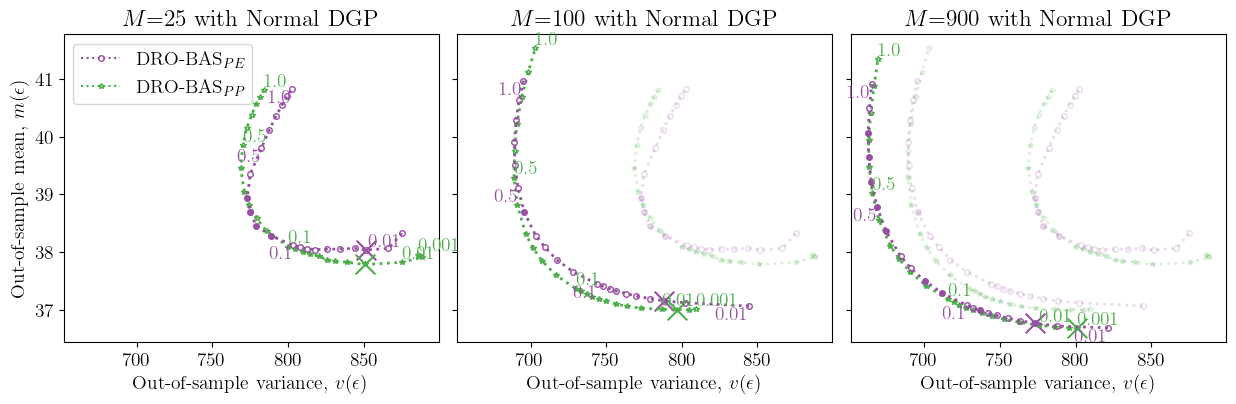

In [17]:
total_samples_list = agg_100_df.loc[~(agg_100_df.index.get_level_values("algorithm").isin(("kl_empirical", "wasserstein_empirical")))].index.get_level_values("num_total_samples").unique().tolist()
# num_observations_list = agg_df.index.get_level_values("num_observations").unique().tolist()
dgp_list = agg_100_df.index.get_level_values("dgp").unique().tolist()

nrows = len(dgp_list)
ncols = len(total_samples_list)
# ncols = len(num_observations_list)
trim_epsilon = 1.0

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*4))
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
for i, dgp in enumerate(dgp_list):
    for j, total_samples in enumerate(total_samples_list):

        # filter by the total samples and DGP
        axis_df = agg_100_df.loc[:, dgp, :, :, total_samples, :]
        # axis_df = agg_100_df.loc[:, dgp, :, :, :, num_observations]
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm, inference in set(zip(axis_df.index.get_level_values("algorithm"), axis_df.index.get_level_values("inference"))):
            df = axis_df.loc[algorithm, :trim_epsilon, :, :]

            if algorithm == "kl_bdro":
                print("All BDRO points are Pareto dominated for M =", total_samples, "?", not df["is_pareto_front"].any())


            for k in range(j, len(total_samples_list)):
            # for k in range(j, len(num_observations_list)):
                alpha = 1.0
                is_labelled=True
                if j != k:
                    alpha = 0.2
                    is_labelled = False
                mean_variance_plot(axes[k], df, **algorithm_inference_style(algorithm, inference, label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)
        if j == 0:
            handles, labels = axes[j].get_legend_handles_labels()
            algorithm_order = [AlgorithmName.kl_dro_bas.value, AlgorithmName.kl_pp.value]
            # algorithm_order = [AlgorithmName.kl_dro_bas.value, AlgorithmName.kl_pp.value, AlgorithmName.kl_bdro.value, AlgorithmName.wasserstein_empirical.value]
            order = [list(labels).index(a) for a in algorithm_order]
            axes[j].legend([handles[idx] for idx in order],[labels[idx] for idx in order])
            axes[j].set_ylabel("Out-of-sample mean, $m(\epsilon)$")
        axes[j].set_title("$M$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        # axes[j].set_title("$n$" + f"={num_observations} with {NiceNameDGP[filter_dgp]}")
        axes[j].set_xlabel("Out-of-sample variance, $v(\epsilon)$")

        # plot where the CV result is on the curve
        for idx, row in cv_agg_df.loc[cv_agg_df.index.get_level_values("num_total_samples") == total_samples].iterrows():
            algorithm = idx[0]
            axes[j].scatter(row["out_of_sample_var"], row["out_of_sample_mean"], marker="x", color=AlgorithmColor[algorithm].value, label=AlgorithmName[algorithm].value, s=200)


fig.savefig(f"/Users/patrick/Experiments/misdro/2025_03_28_cross_validation/cross_validation_newsvendor_{filter_dgp}_100_observations.pdf", bbox_inches="tight")